In [1]:
from pathlib import Path
import sys

import tabpfn
import torch


CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)
print("TabPFN:", tabpfn.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Project root: D:\AST\05B_JADES_Foundation
Python: D:\conda_envs\jades_fm\python.exe
TabPFN: 8.4.0
PyTorch: 2.12.1+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


C:\Users\howto\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. TabPFN residual foundation model

TabPFN v3 uses the frozen JADES training catalog as in-context examples and predicts the log-redshift residual of EAZY.

TabPFN inference: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:05<00:00,  1.41estimator/s]


,method,sources,normalized_bias,normalized_median_absolute_error,sigma_nmad,mean_absolute_redshift_error,catastrophic_outliers,catastrophic_outlier_fraction,runtime_seconds
0,EAZY DR5 z_a,476,0.012392,0.022105,0.027172,0.212583,20,0.042017,7.327625
1,TabPFN v3: EAZY log-residual,476,0.000950,0.014102,0.021022,0.120912,14,0.029412,7.327625


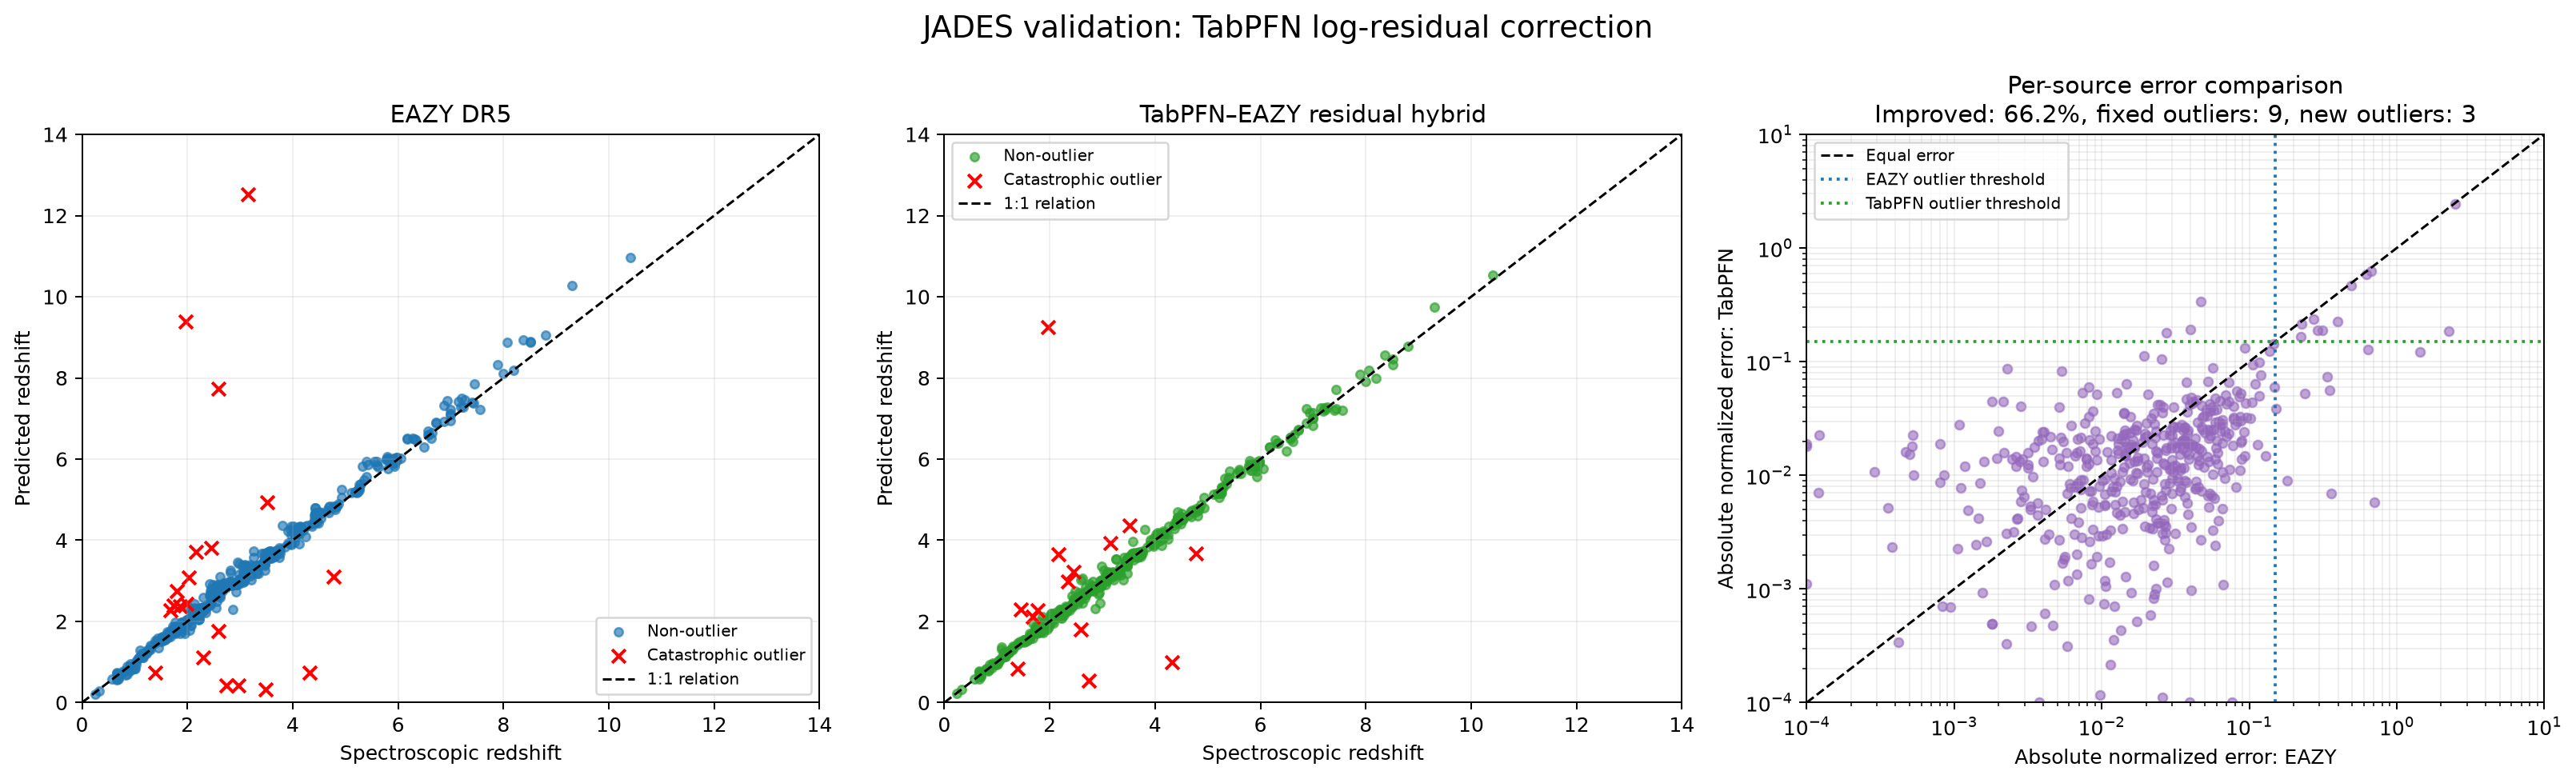

In [2]:
from IPython.display import Image, display

from src.tabpfn import run_tabpfn_validation_experiment

(
    tabpfn_validation_metrics,
    tabpfn_validation_predictions,
    tabpfn_validation_figure,
) = run_tabpfn_validation_experiment()

display(tabpfn_validation_metrics)
display(
    Image(
        filename=str(tabpfn_validation_figure)
    )
)

## 3. Foundation-model ablation

TabPFN inference: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:04<00:00,  1.68estimator/s]


,method,sources,normalized_bias,normalized_median_absolute_error,sigma_nmad,mean_absolute_redshift_error,catastrophic_outliers,catastrophic_outlier_fraction,training_rows,feature_count,uses_eazy,runtime_seconds,validation_rank
0,EAZY DR5 z_a,476,0.012392,0.022105,0.027172,0.212583,20,0.042017,0,0,False,NaN,4
1,TabPFN v3: photometry only,476,0.002436,0.015075,0.022060,0.163329,30,0.063025,2219,57,False,4.415543,3
2,TabPFN v3: EAZY residual,476,0.000950,0.014102,0.021022,0.120912,14,0.029412,2219,66,True,7.327625,1
3,TabPFN v3: resampled EAZY residual,476,0.000949,0.014490,0.022099,0.124585,14,0.029412,2795,66,True,5.424873,2


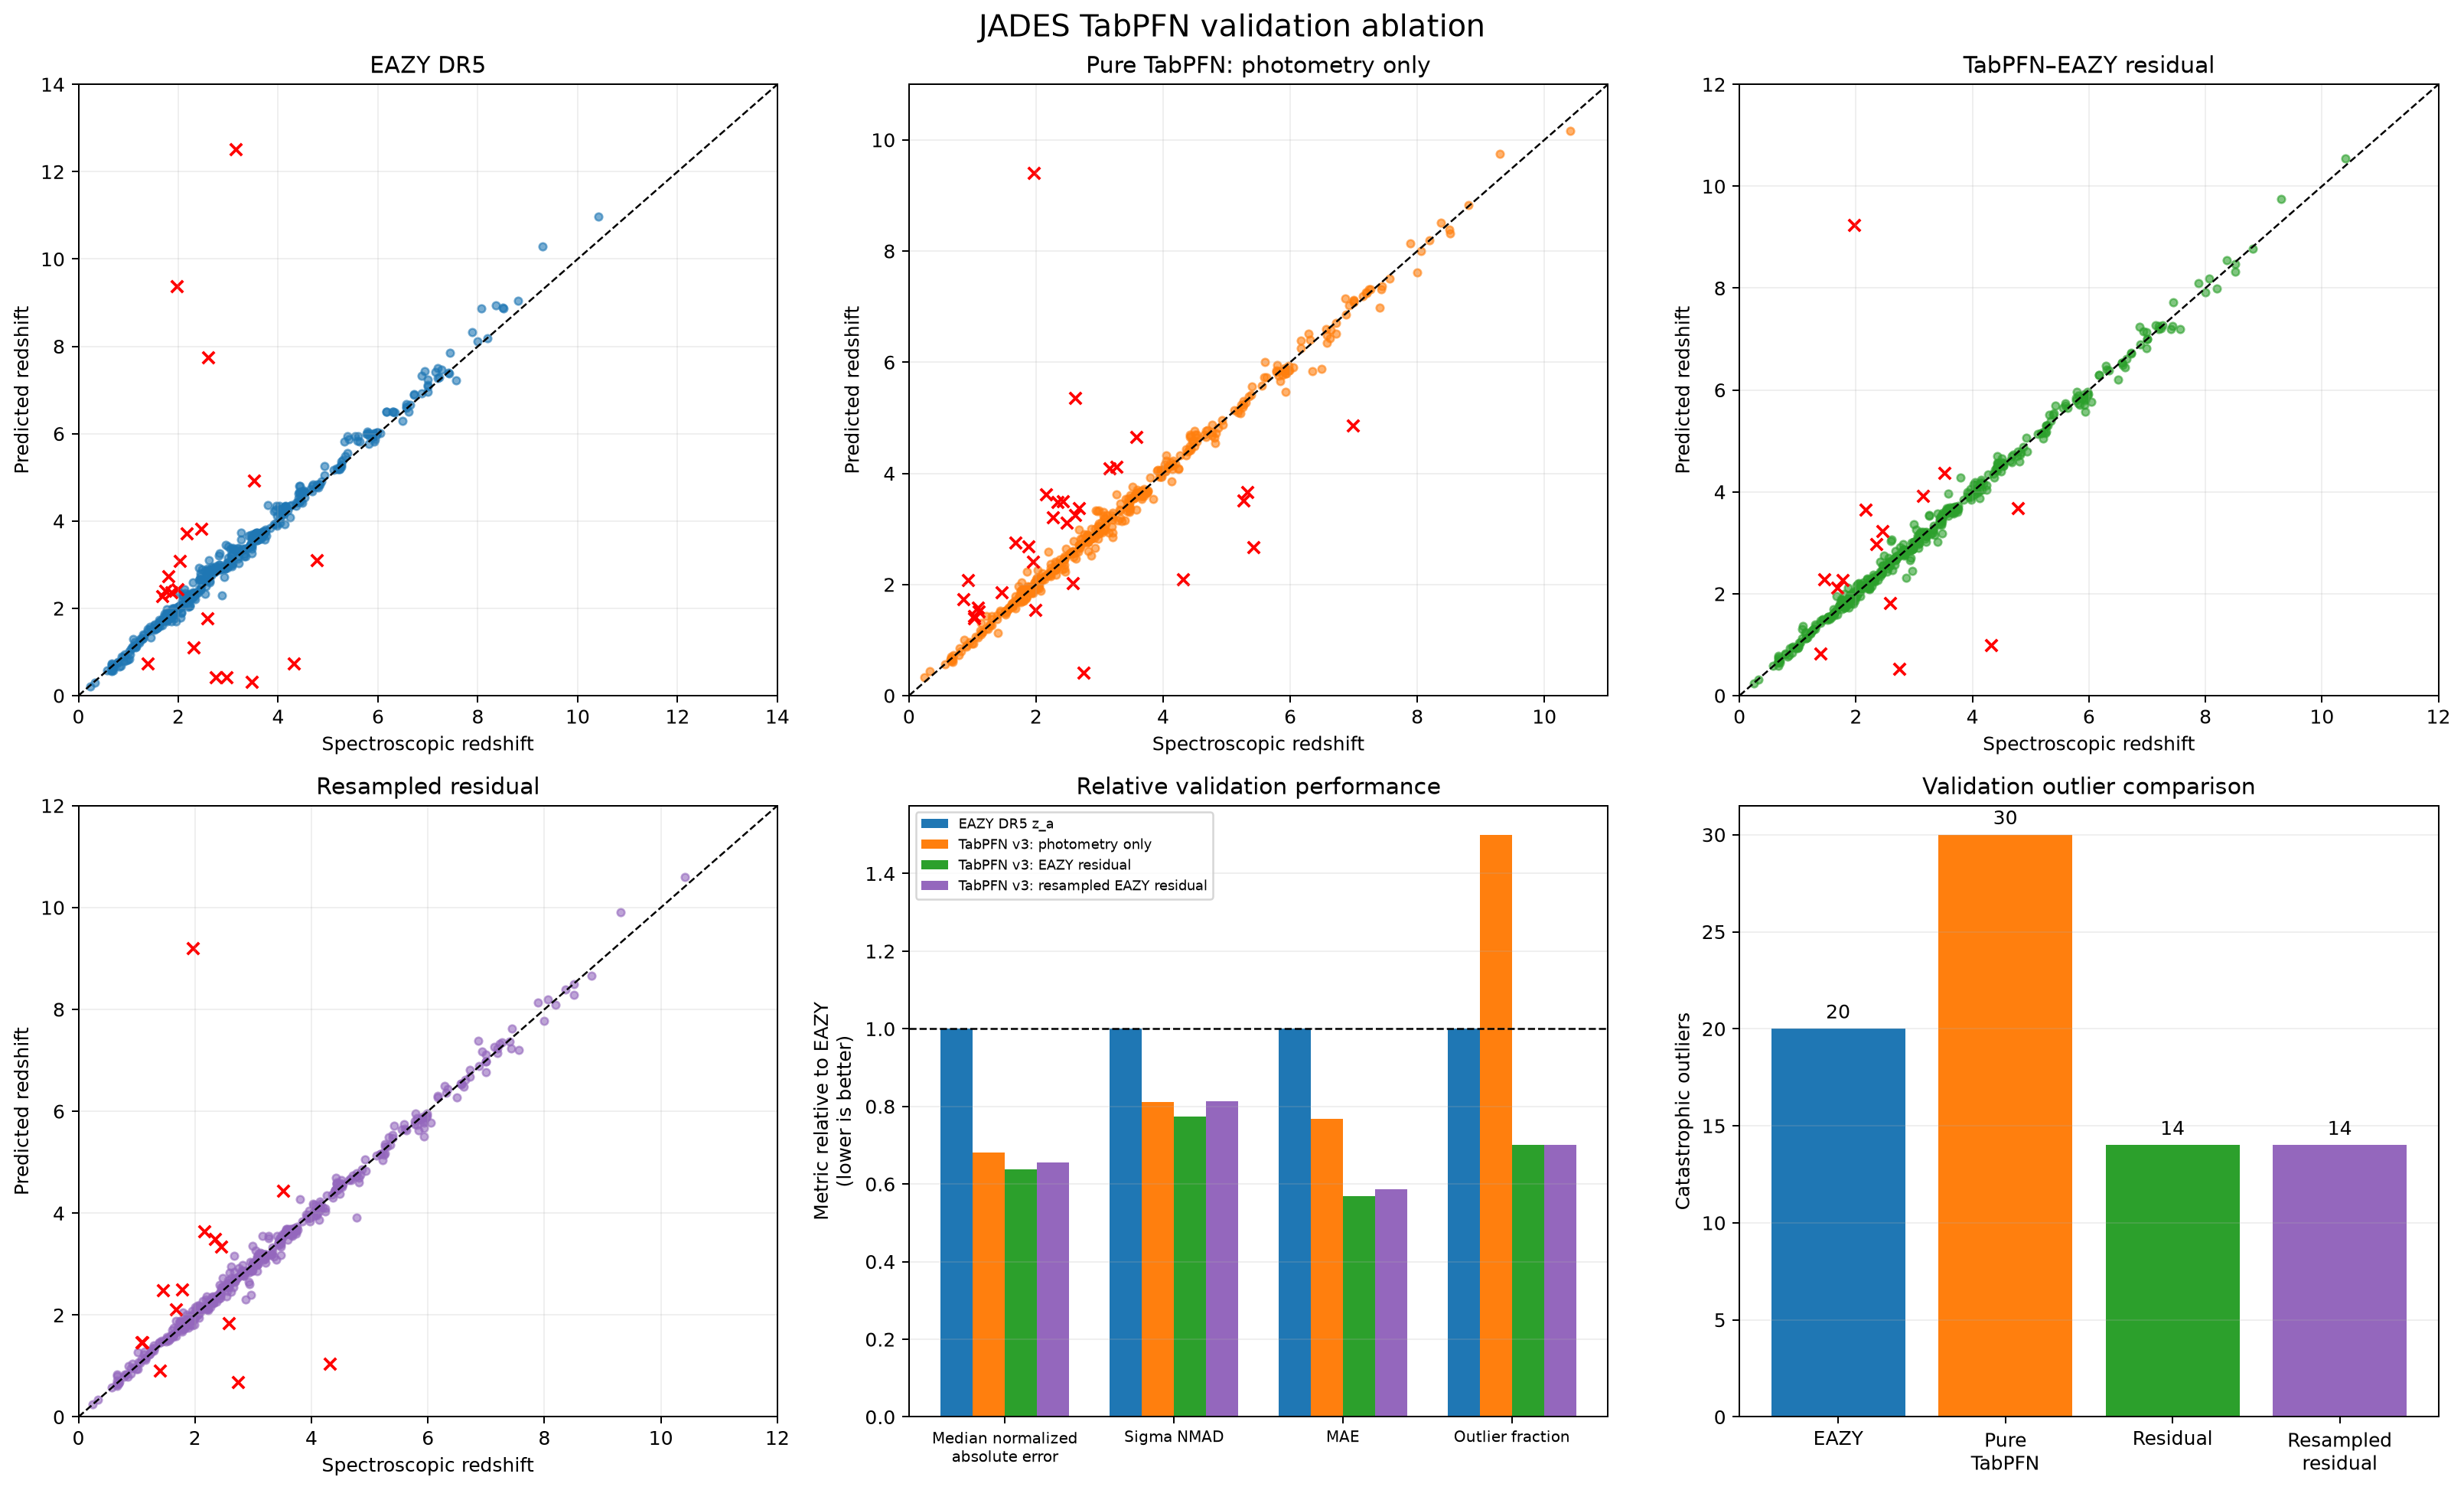

In [3]:
from IPython.display import Image, display

from src.ablation import run_tabpfn_ablation

(
    tabpfn_ablation_metrics,
    tabpfn_ablation_predictions,
    tabpfn_ablation_figure,
) = run_tabpfn_ablation()

display(tabpfn_ablation_metrics)
display(
    Image(
        filename=str(tabpfn_ablation_figure)
    )
)

## 4. EAZY, XGBoost, gated XGBoost–EAZY,TabPFN, TabPFN–EAZY residual predictions 

,validation_rank,method,role,sources,normalized_bias,normalized_median_absolute_error,sigma_nmad,mean_absolute_redshift_error,catastrophic_outliers,catastrophic_outlier_fraction
0,4,EAZY DR5 z_a,Template-fitting benchmark,476,0.012392,0.022105,0.027172,0.212583,20,0.042017
1,5,XGBoost: photometry only,Traditional ML baseline,476,0.004897,0.066669,0.099464,0.465449,106,0.222689
2,3,XGBoost: gated EAZY residual,Traditional ML hybrid,476,0.003498,0.016529,0.024317,0.177573,19,0.039916
3,2,TabPFN v3: photometry only,Foundation-model baseline,476,0.002436,0.015075,0.022060,0.163329,30,0.063025
4,1,TabPFN v3: EAZY residual,Foundation-model hybrid,476,0.000950,0.014102,0.021022,0.120912,14,0.029412


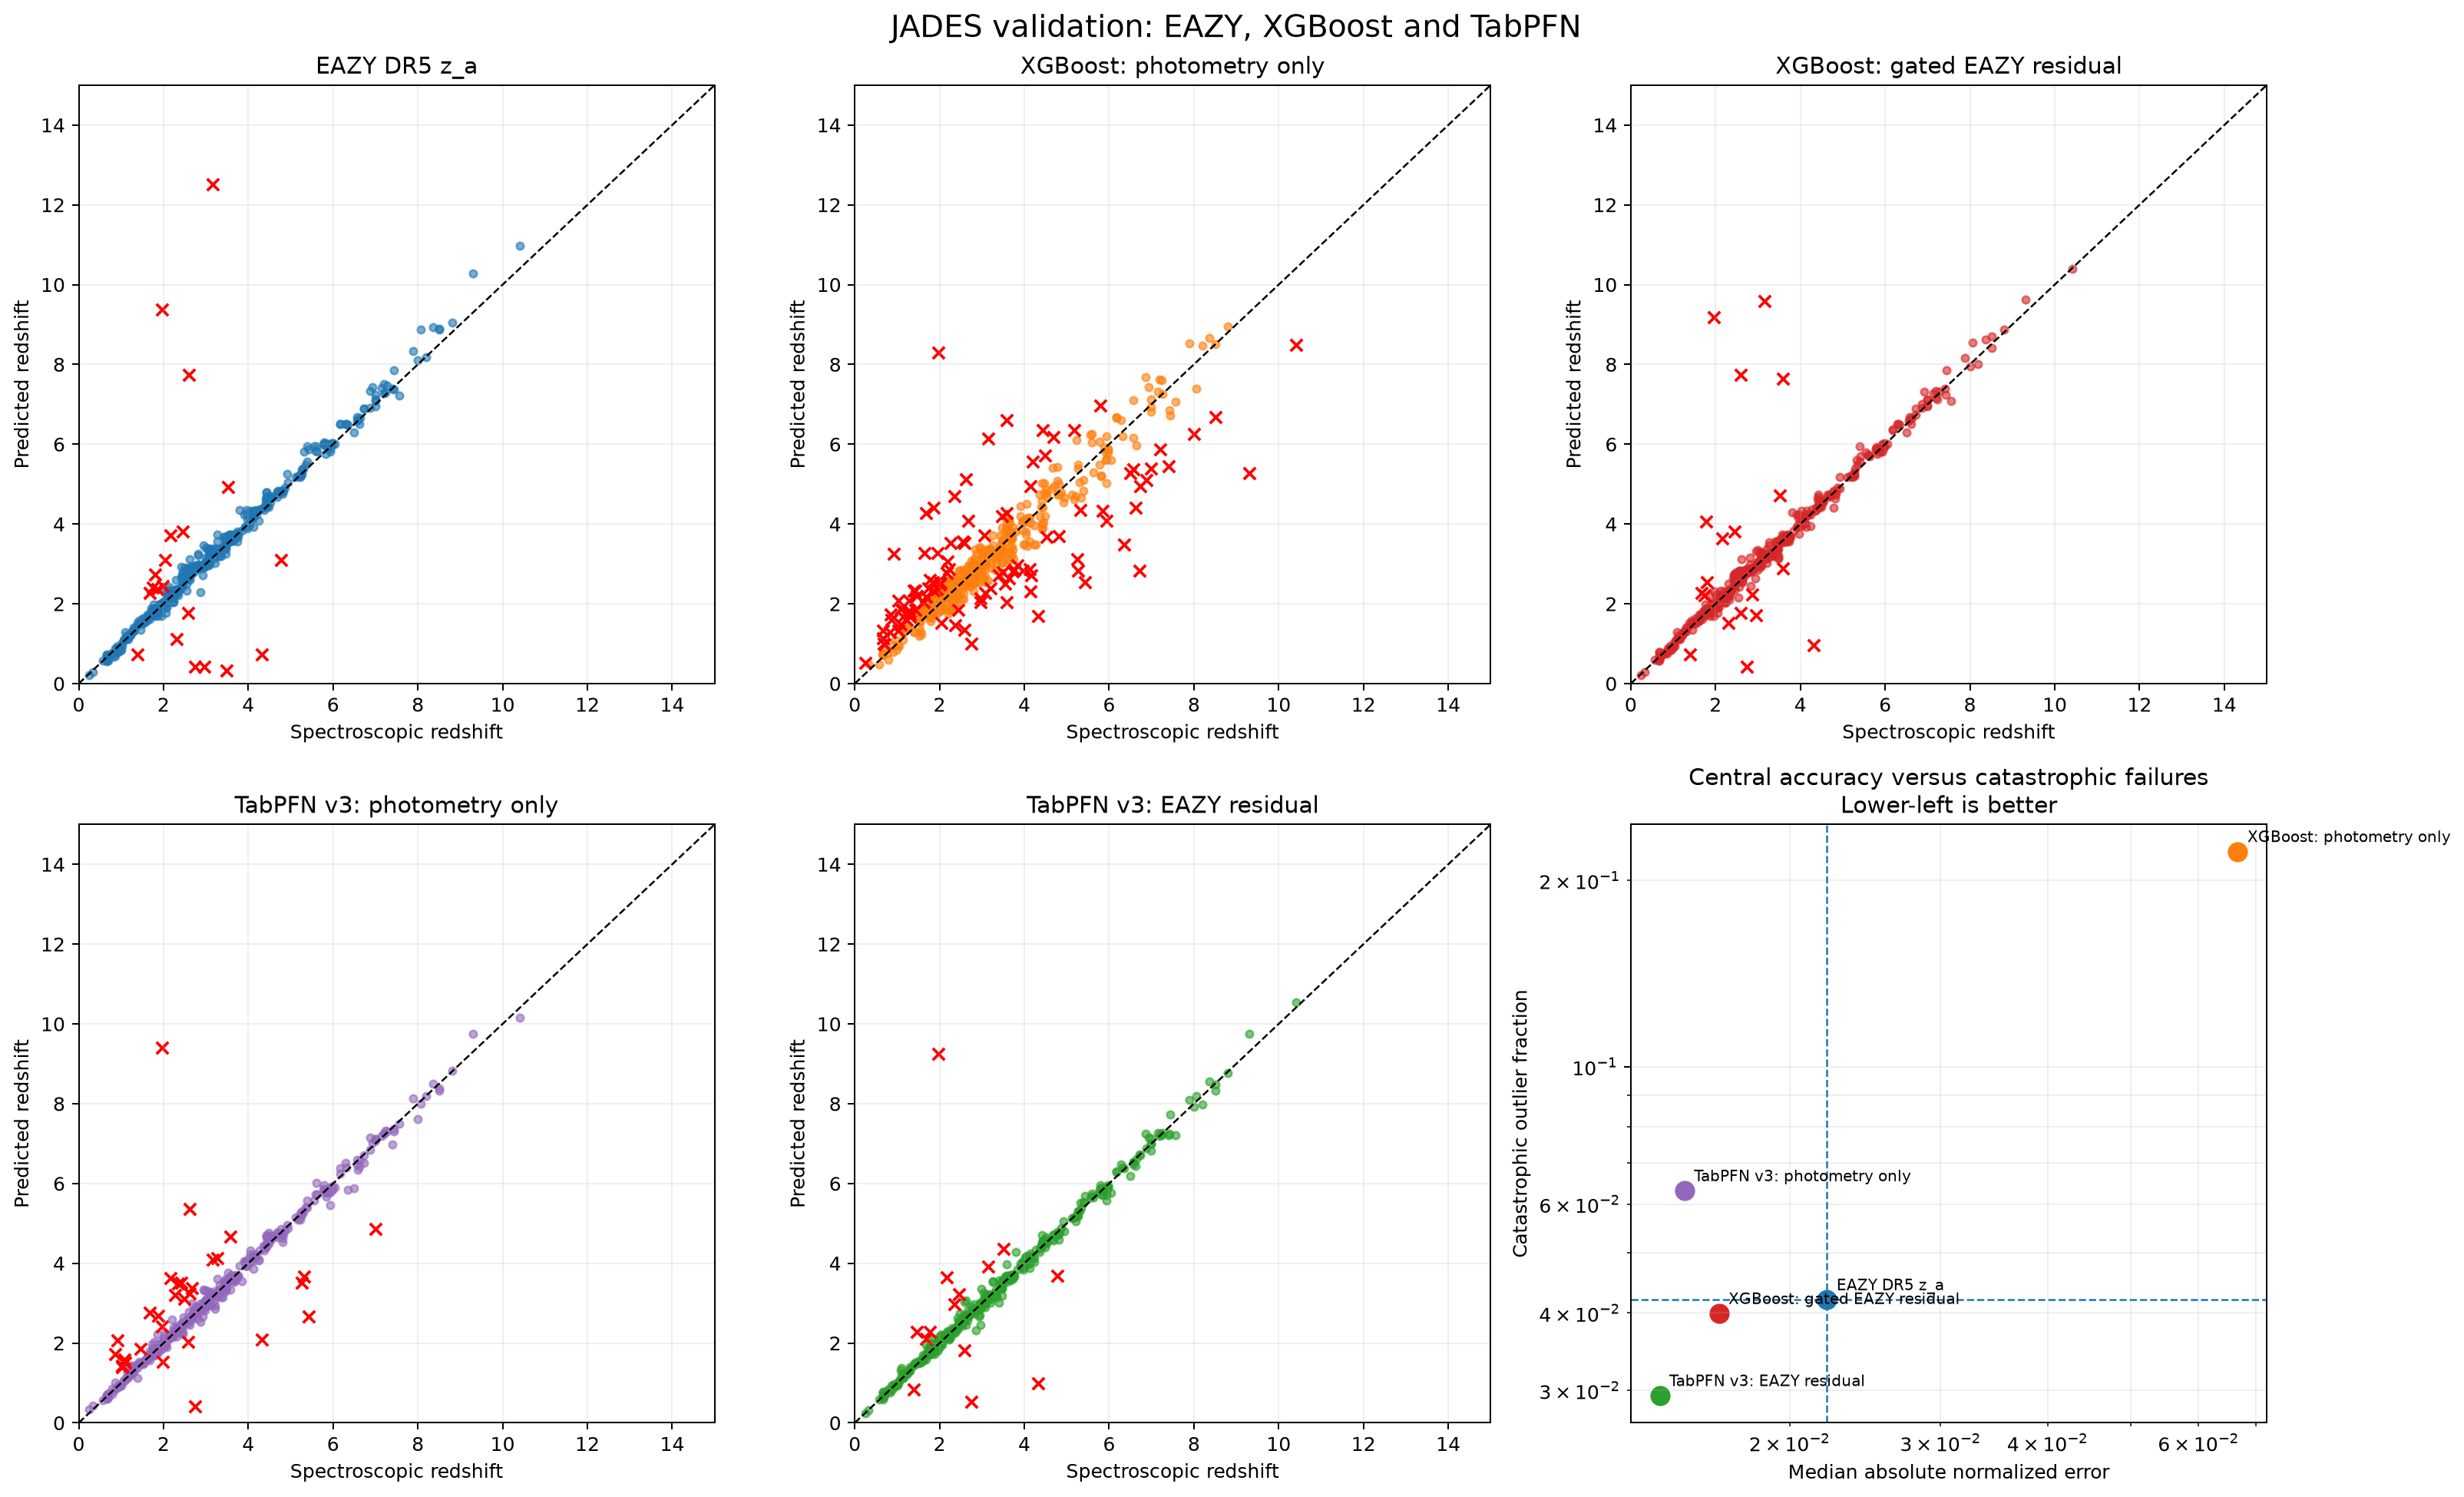

In [4]:
from IPython.display import Image, display

from src.comparison import (
    run_five_method_validation_comparison,
)

(
    five_method_metrics,
    five_method_predictions,
    five_method_figure,
) = run_five_method_validation_comparison()

display(five_method_metrics)

display(
    Image(
        filename=str(five_method_figure)
    )
)

## 5. TabPFN blind test

TabPFN inference: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:04<00:00,  1.90estimator/s]


,blind_test_rank,method,role,sources,normalized_bias,normalized_median_absolute_error,sigma_nmad,mean_absolute_redshift_error,catastrophic_outliers,catastrophic_outlier_fraction,runtime_seconds
0,4,EAZY DR5 z_a,Template-fitting benchmark,476,0.010433,0.017061,0.021029,0.170490,20,0.042017,NaN
1,5,XGBoost: photometry only,Frozen Task 5A traditional ML baseline,476,-0.002838,0.058638,0.087048,0.421305,97,0.203782,NaN
2,3,XGBoost: gated EAZY residual,Frozen Task 5A traditional ML hybrid,476,0.003361,0.014293,0.022499,0.135674,16,0.033613,NaN
3,2,TabPFN v3: photometry only,Frozen foundation-model ablation,476,0.001318,0.013875,0.020546,0.145296,25,0.052521,4.865488
4,1,TabPFN v3: EAZY residual,Preselected primary foundation-model hybrid,476,0.000218,0.011210,0.016599,0.094889,15,0.031513,4.838083


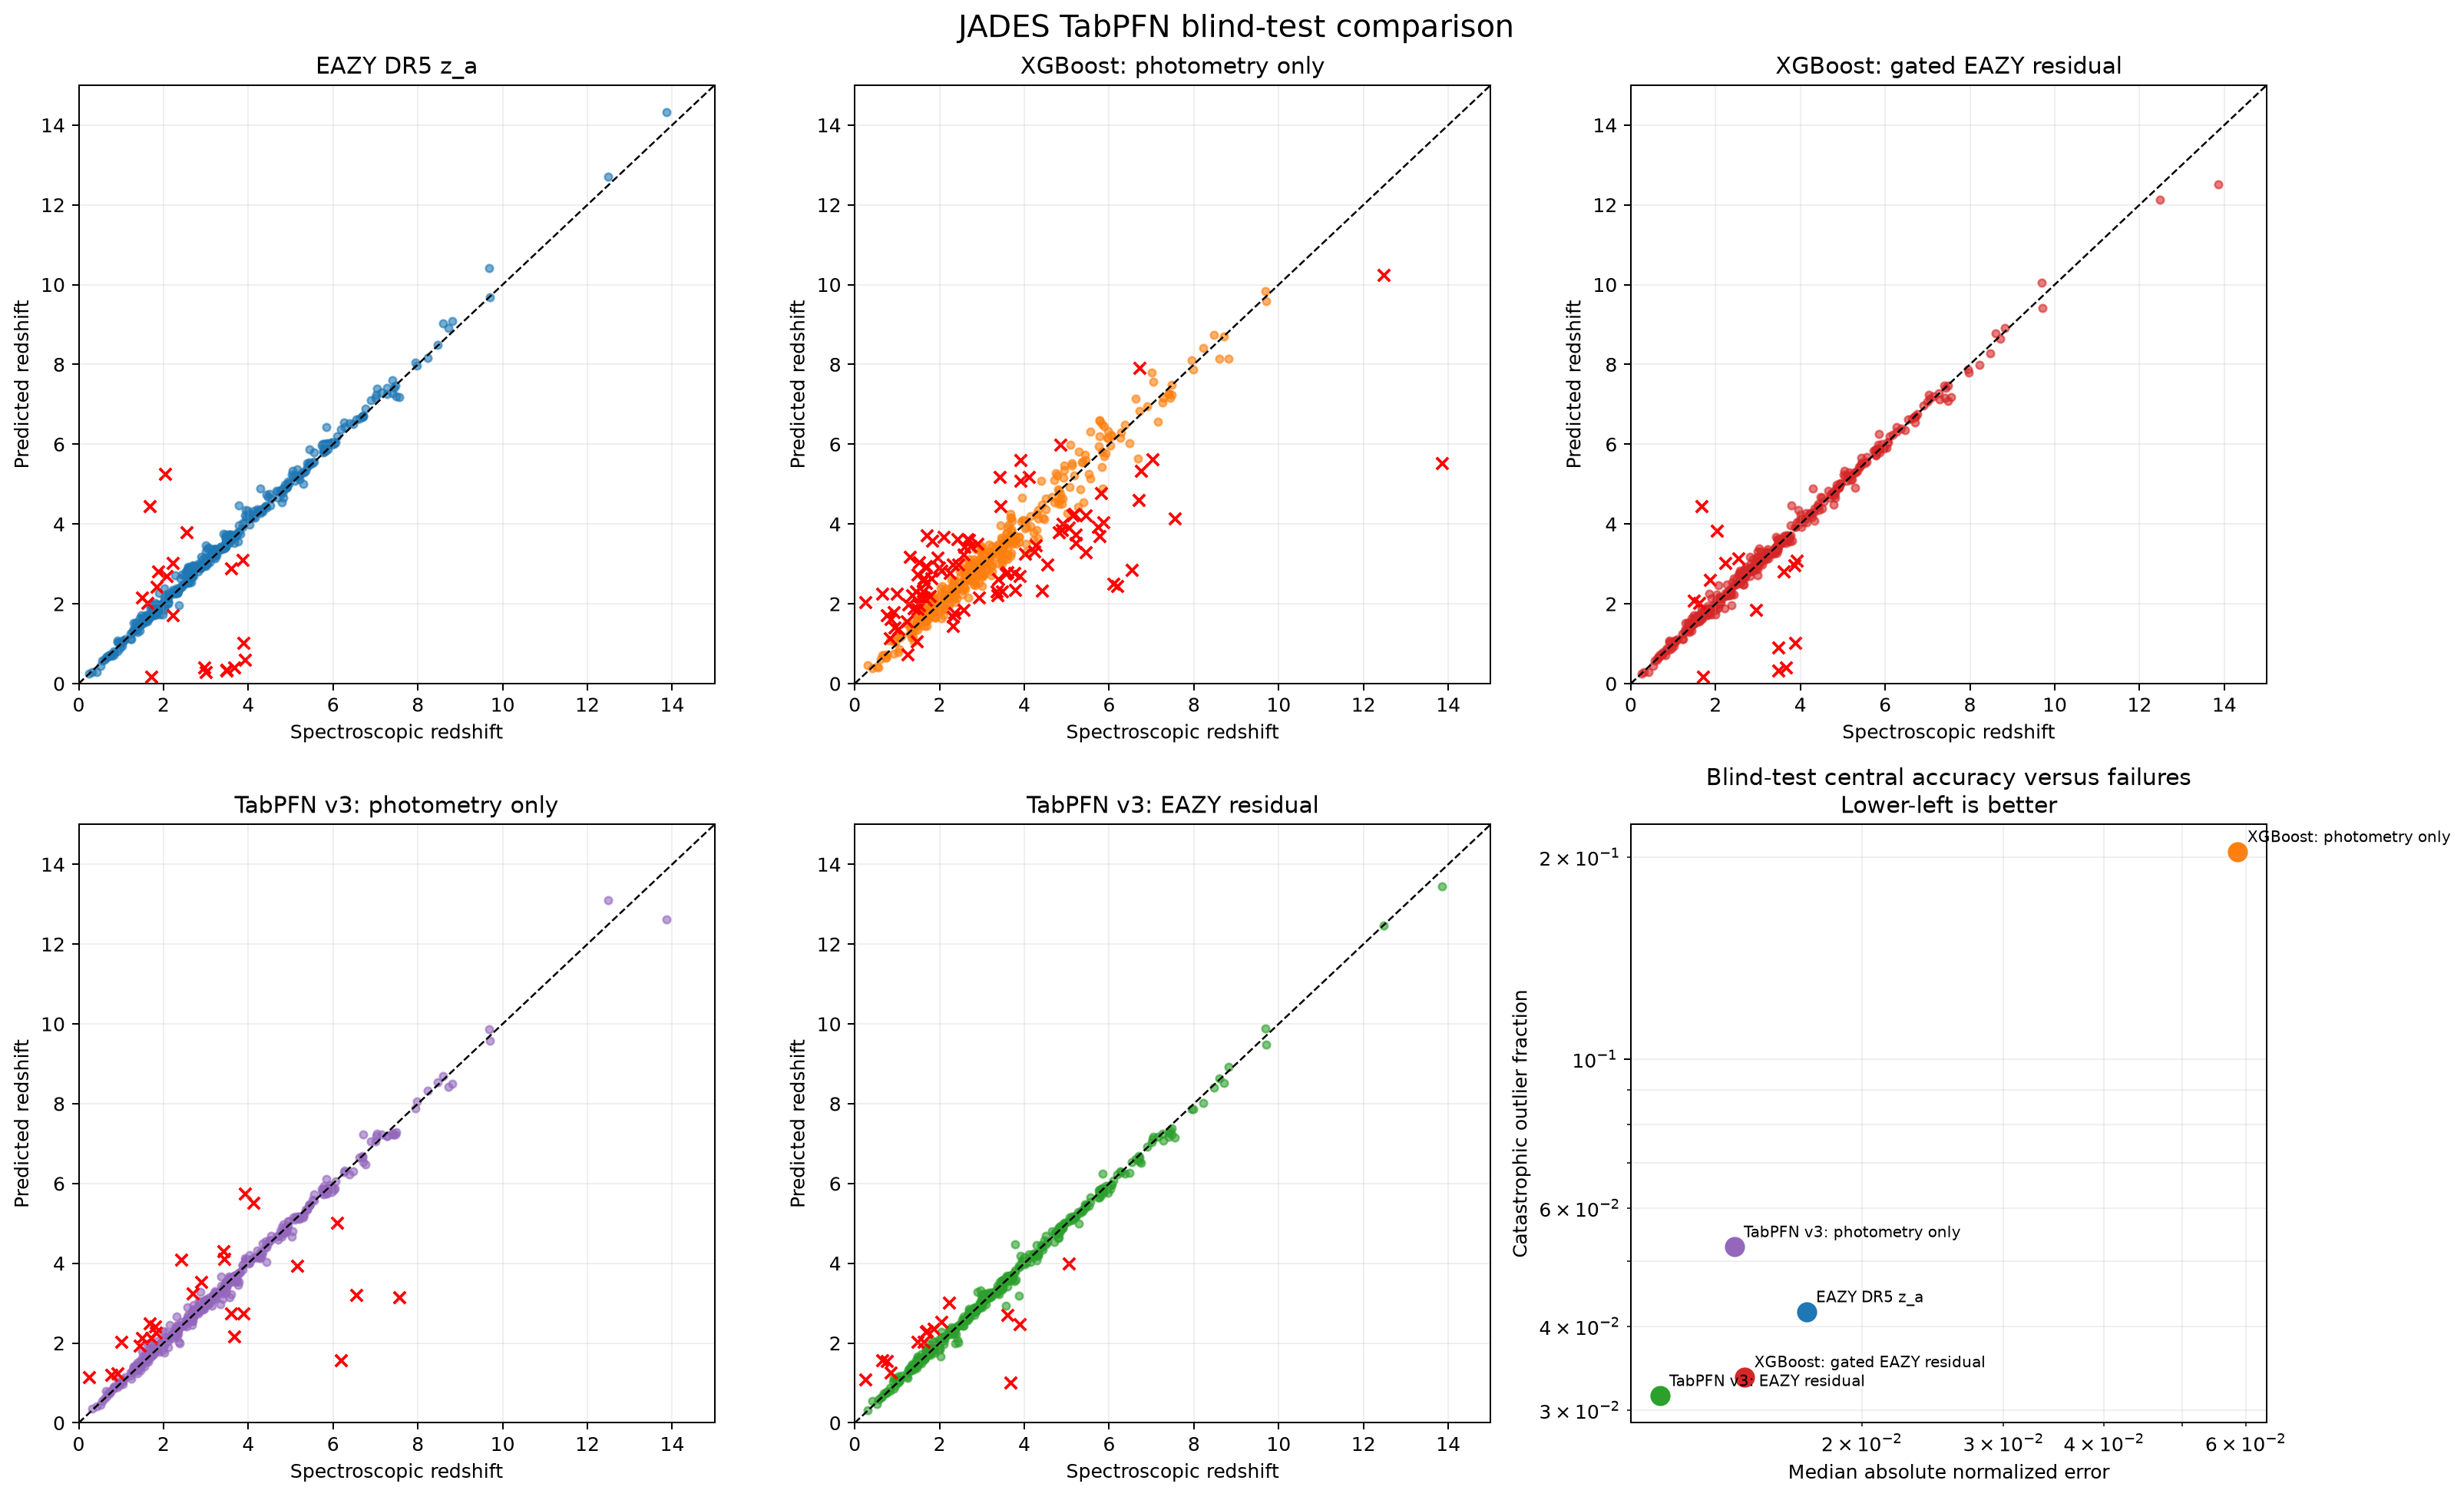

In [5]:
from IPython.display import Image, display

from src.blind_test import (
    run_tabpfn_blind_test,
)

(
    blind_test_metrics,
    blind_test_predictions,
    blind_test_figure,
) = run_tabpfn_blind_test()

display(blind_test_metrics)

display(
    Image(
        filename=str(blind_test_figure)
    )
)

## 6. EAZY and TabPFN contributions

,metric,value
0,Blind-test sources,476.000000
1,Sources improved by TabPFN,302.000000
2,Fraction improved by TabPFN,0.634454
3,Sources worsened by TabPFN,174.000000
4,Fraction worsened by TabPFN,0.365546
5,EAZY outliers fixed by TabPFN,10.000000
6,New outliers introduced by TabPFN,5.000000
7,Outliers shared by both methods,10.000000
8,Correction-direction agreement,0.775210
9,True-versus-applied residual correlation,0.902976


,case_group,source_key,z_spec,z_eazy,z_tabpfn_eazy,redshift_correction,eazy_absolute_normalized_error,hybrid_absolute_normalized_error,normalized_error_improvement,outlier_transition
0,Fixed EAZY outlier,GS:315258,3.482116,0.32,3.399859,3.079859,0.705496,0.018352,0.687144,Fixed EAZY outlier
1,Fixed EAZY outlier,GS:245893,3.486452,0.35,3.381962,3.031962,0.699094,0.023290,0.675804,Fixed EAZY outlier
2,Shared outlier,GN:1238092,3.664738,0.41,1.002812,0.592812,0.697732,0.570648,0.127084,Shared outlier
3,Shared outlier,GS:73753,3.886783,1.02,2.475536,1.455536,0.586640,0.288788,0.297852,Shared outlier
4,New hybrid outlier,GN:1067323,0.253300,0.25,1.094943,0.844943,0.002633,0.671542,-0.668909,New hybrid outlier
5,New hybrid outlier,GS:393648,0.644245,0.65,1.570266,0.920266,0.003500,0.563189,-0.559689,New hybrid outlier
6,Largest ordinary improvement,GS:303480,1.294895,1.53,1.303882,-0.226118,0.102447,0.003916,0.098531,Non-outlier in both
7,Largest ordinary improvement,GN:1009377,2.575369,2.92,2.579315,-0.340684,0.096390,0.001104,0.095287,Non-outlier in both
8,Largest ordinary harm,GS:309703,2.432877,2.42,2.008644,-0.411355,0.003751,0.123579,-0.119828,Non-outlier in both
9,Largest ordinary harm,GS:329422,3.559900,3.73,2.938499,-0.791502,0.037303,0.136275,-0.098972,Non-outlier in both


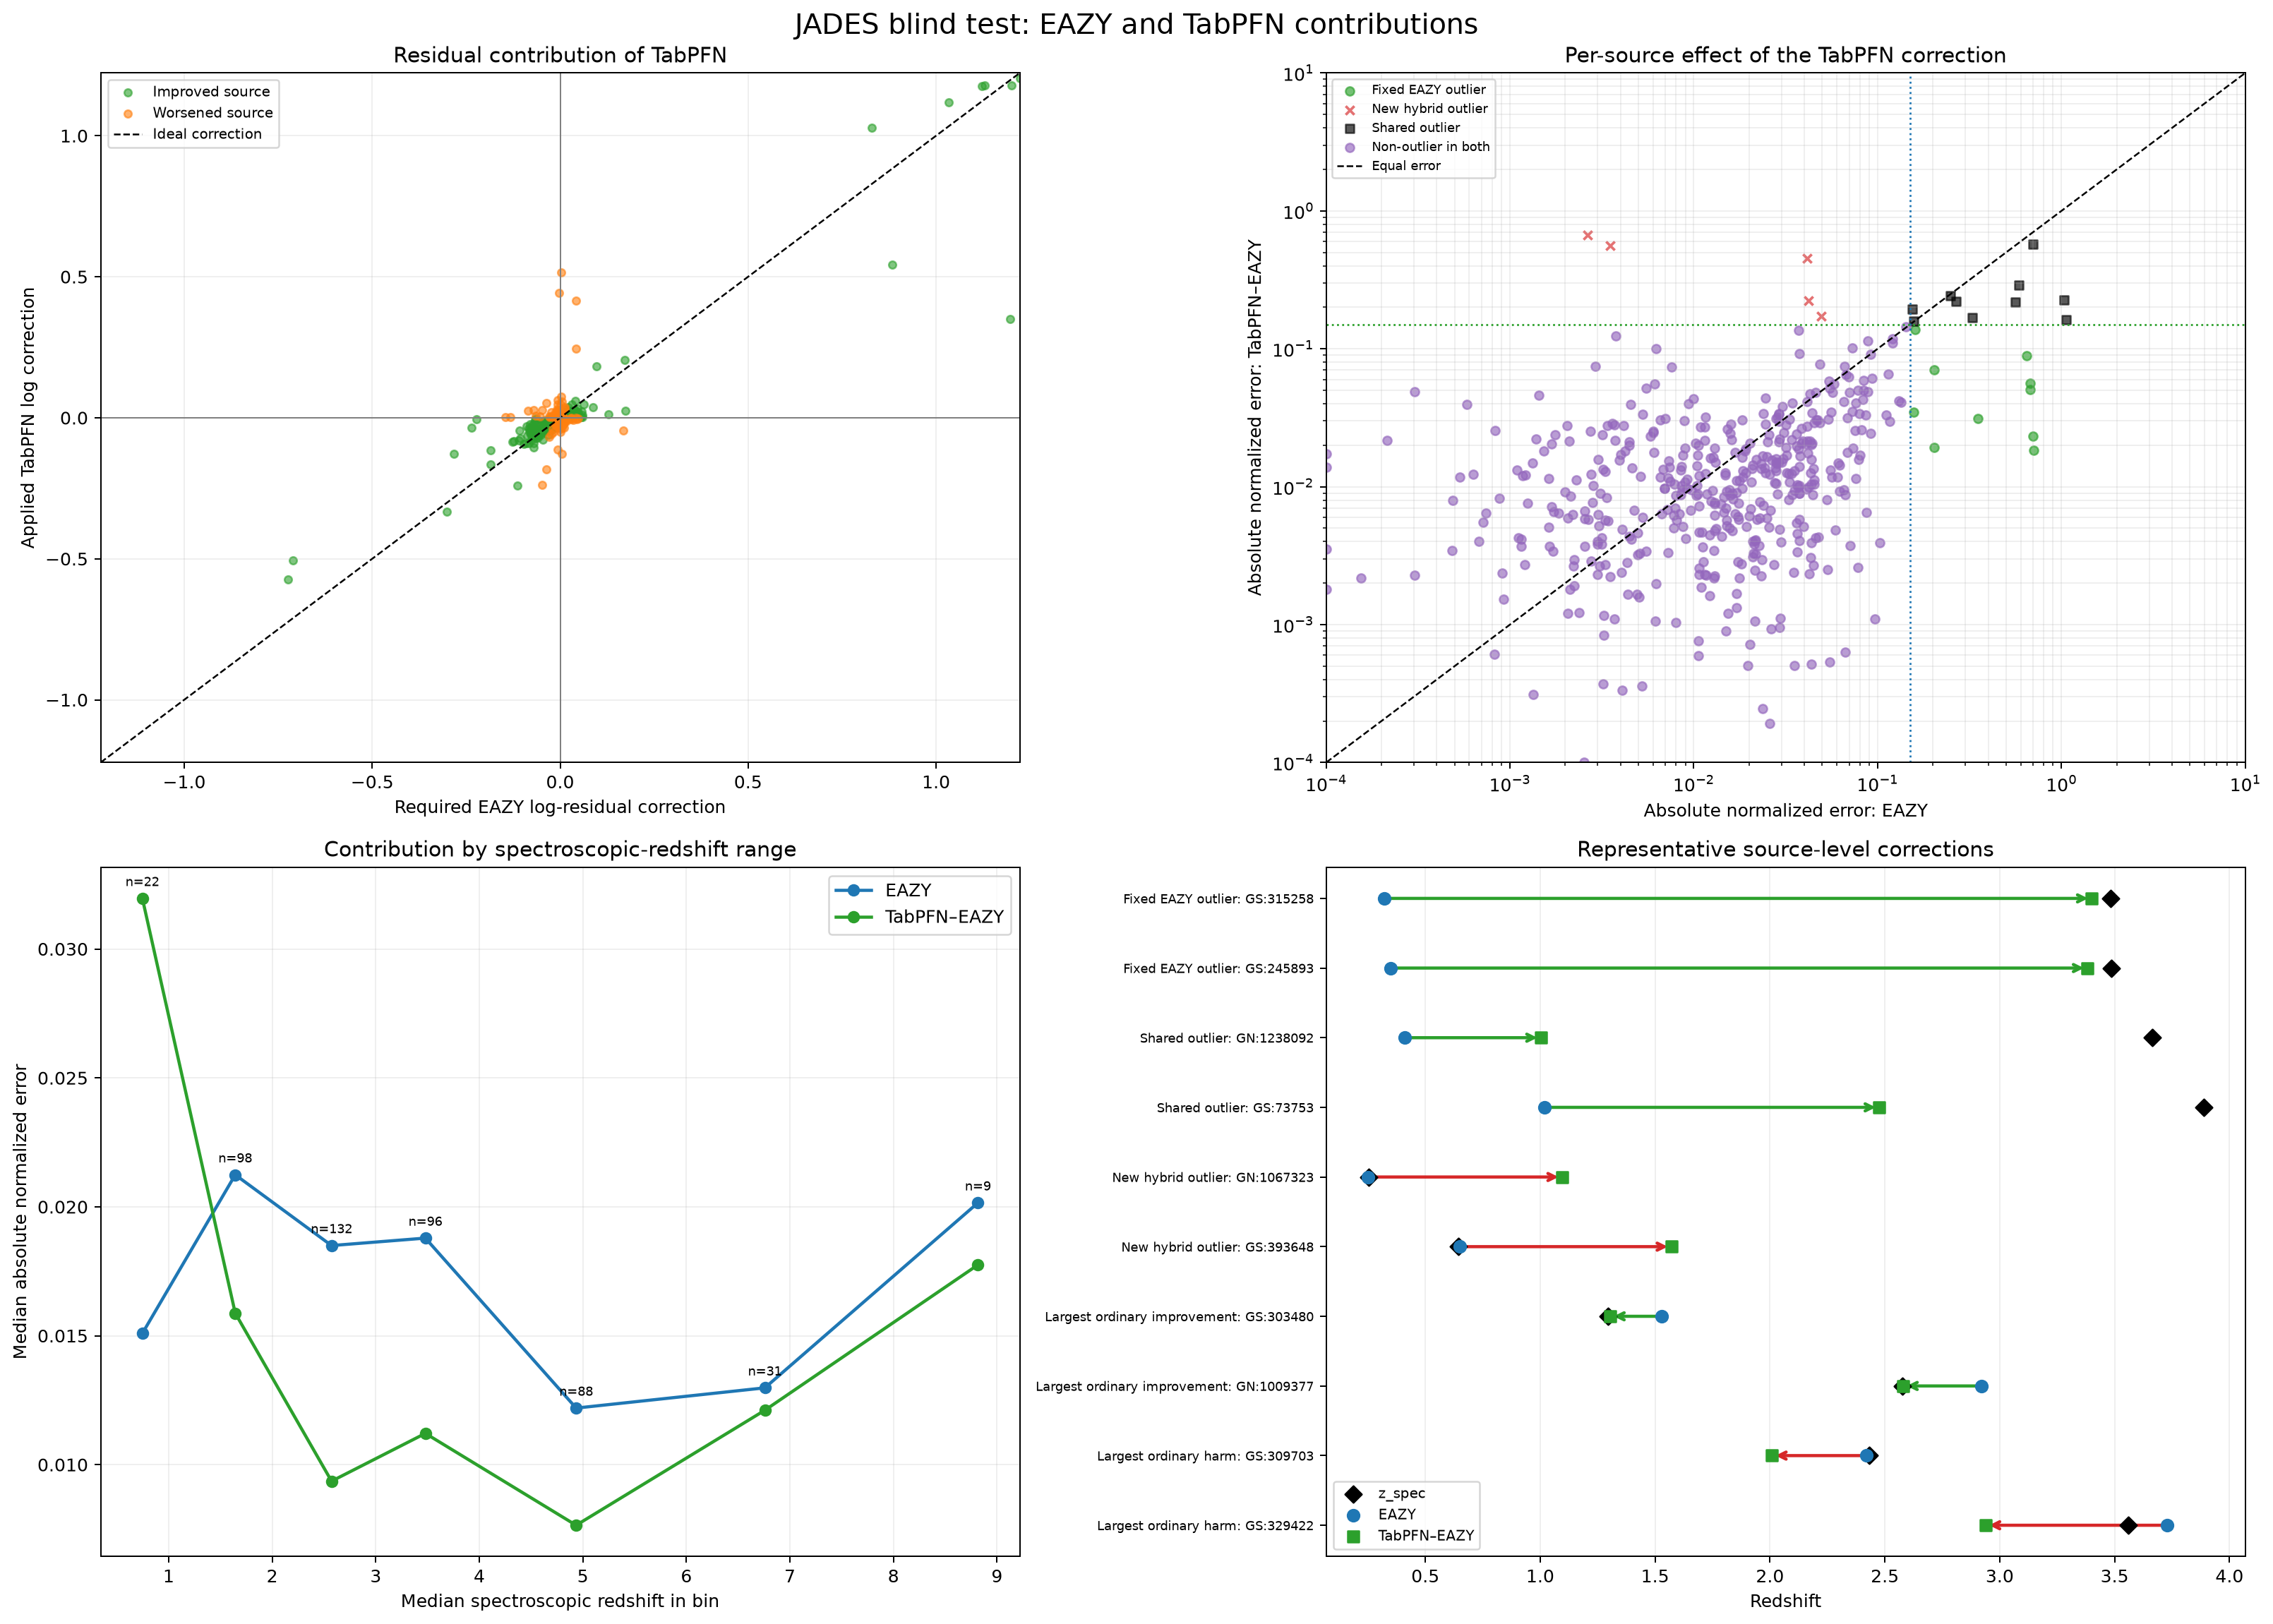

In [6]:
from IPython.display import Image, display

from src.contributions import (
    run_contribution_analysis,
)

(
    contribution_summary,
    contribution_cases,
    contribution_figure,
) = run_contribution_analysis()

display(contribution_summary)
display(contribution_cases)

display(
    Image(
        filename=str(contribution_figure)
    )
)